## 1. Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (15159, 3)


,review,aspect,sentiment
0,"_ Ảnh chụp từ hôm qua, đi chơi với gia đình và...",FOOD#QUALITY,positive
1,"_ Ảnh chụp từ hôm qua, đi chơi với gia đình và...",FOOD#STYLE&OPTIONS,positive
2,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",AMBIENCE#GENERAL,negative
3,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",FOOD#PRICES,positive
4,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",FOOD#QUALITY,negative
5,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",FOOD#STYLE&OPTIONS,negative
6,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",RESTAURANT#GENERAL,negative
7,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",RESTAURANT#PRICES,positive
8,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",SERVICE#GENERAL,neutral
9,- 1 bàn tiệc hoành tráng 3 đứa ăn no muốn tắt ...,AMBIENCE#GENERAL,neutral


In [2]:
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 15159 entries, 0 to 15158
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     15159 non-null  str  
 1   aspect     15159 non-null  str  
 2   sentiment  15159 non-null  str  
dtypes: str(3)
memory usage: 7.8 MB


review       0
aspect       0
sentiment    0
dtype: int64

## 2. Basic Counts

In [3]:
print("Total rows     :", len(df))
print("Unique reviews :", df['review'].nunique())
print("Unique aspects :", df['aspect'].nunique())
print("Sentiment classes:", df['sentiment'].unique())

Total rows     : 15159
Unique reviews : 4711
Unique aspects : 12
Sentiment classes: <ArrowStringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str


## 3. Sentiment Distribution

In [4]:
df['sentiment'].value_counts()

sentiment
negative    11260
positive     2839
neutral      1060
Name: count, dtype: int64

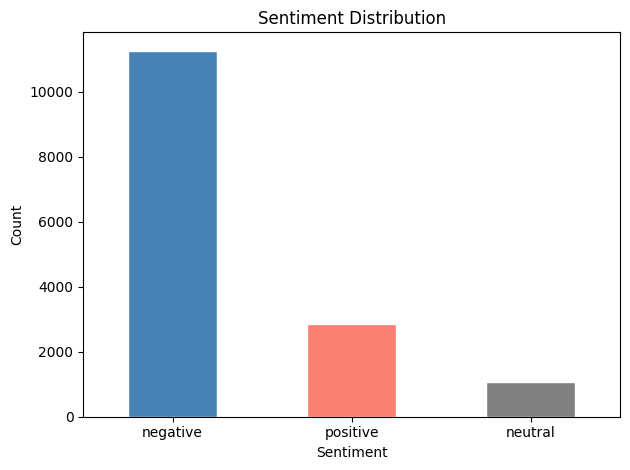

In [5]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['steelblue', 'salmon', 'gray'], edgecolor='white')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Aspect Distribution

In [6]:
df['aspect'].value_counts()

aspect
FOOD#QUALITY                4275
FOOD#STYLE&OPTIONS          2665
FOOD#PRICES                 2456
RESTAURANT#GENERAL          1309
SERVICE#GENERAL             1198
AMBIENCE#GENERAL            1197
LOCATION#GENERAL             686
RESTAURANT#MISCELLANEOUS     398
RESTAURANT#PRICES            371
DRINKS#QUALITY               224
DRINKS#PRICES                222
DRINKS#STYLE&OPTIONS         158
Name: count, dtype: int64

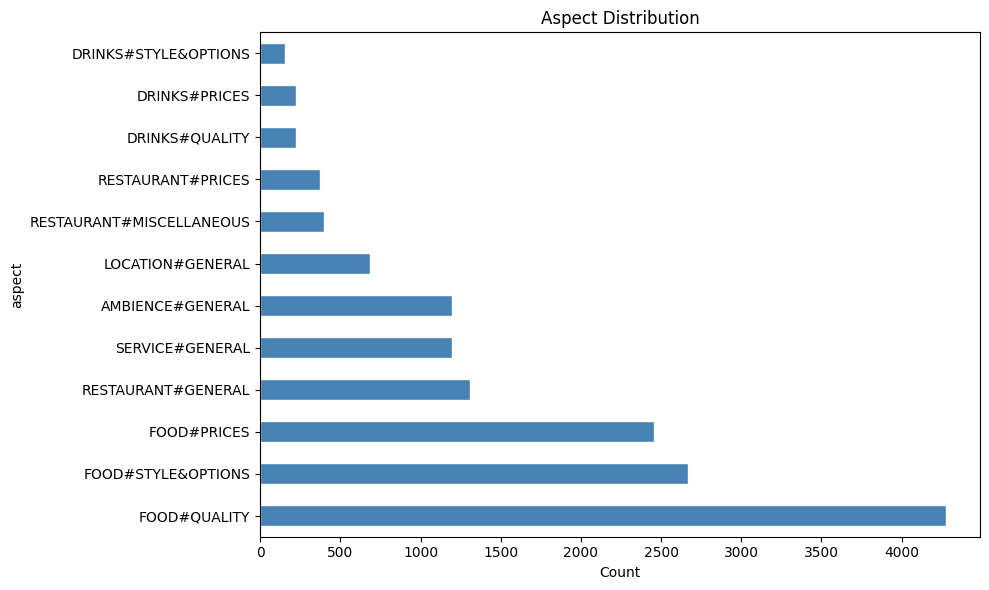

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
df['aspect'].value_counts().plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Aspect Distribution')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 5. Sentiment by Aspect

In [8]:
pivot = df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)
pivot['negative_rate'] = (pivot['negative'] / pivot.sum(axis=1)).round(2)
pivot.sort_values('negative_rate', ascending=False)

sentiment,negative,neutral,positive,negative_rate
aspect,,,,
RESTAURANT#GENERAL,1213,55,41,0.93
DRINKS#STYLE&OPTIONS,144,8,6,0.91
FOOD#QUALITY,3745,92,438,0.88
FOOD#STYLE&OPTIONS,2272,154,239,0.85
DRINKS#QUALITY,176,21,27,0.79
SERVICE#GENERAL,920,164,114,0.77
AMBIENCE#GENERAL,843,151,203,0.70
RESTAURANT#PRICES,226,30,115,0.61
DRINKS#PRICES,114,18,90,0.51


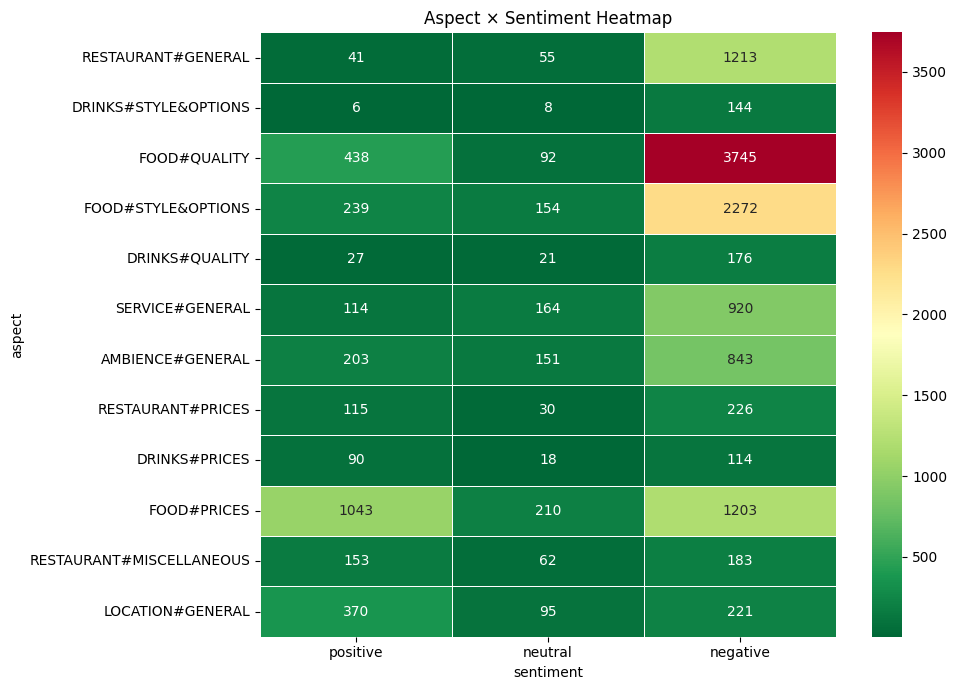

In [9]:
sentiment_cols = [col for col in ['positive', 'neutral', 'negative'] if col in pivot.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(pivot.sort_values('negative_rate', ascending=False)[sentiment_cols],
            annot=True, fmt='d', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Aspect × Sentiment Heatmap')
plt.tight_layout()
plt.show()

## 6. Review Length Analysis

In [10]:
df['word_count'] = df['review'].str.split().str.len()
df['word_count'].describe()

count    15159.000000
mean        87.042813
std         76.226451
min          1.000000
25%         39.000000
50%         65.000000
75%        103.000000
max        967.000000
Name: word_count, dtype: float64

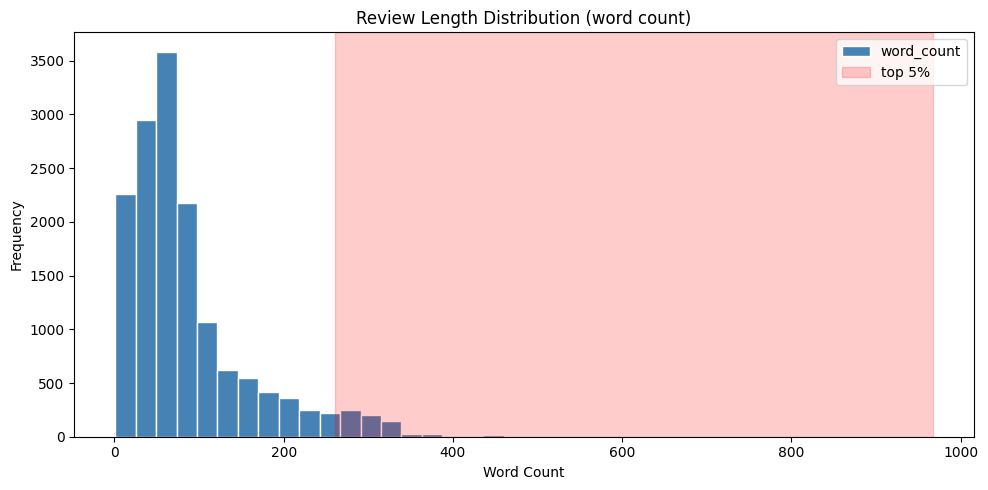

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df['word_count'].plot(kind='hist', bins=40, color='steelblue', edgecolor='white', ax=ax)
ax.axvspan(df['word_count'].quantile(0.95), df['word_count'].max(), alpha=0.2, color='red', label='top 5%')
ax.set_title('Review Length Distribution (word count)')
ax.set_xlabel('Word Count')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Aspects per Review

In [12]:
aspects_per_review = df.groupby('review')['aspect'].count()
print("Max aspects in one review:", aspects_per_review.max())
aspects_per_review.value_counts().sort_index()

Max aspects in one review: 11


aspect
1      668
2     1112
3     1124
4      797
5      598
6      253
7       99
8       40
9       15
10       4
11       1
Name: count, dtype: int64

## 8. Sample Reviews

In [13]:
print("=== POSITIVE samples ===")
for _, row in df[df['sentiment'] == 'positive'][['review', 'aspect']].sample(3, random_state=42).iterrows():
    print(f"  [{row['aspect']}]")
    print(f" - {row['review']}\n")

print("\n=== NEUTRAL samples ===")
for _, row in df[df['sentiment'] == 'neutral'][['review', 'aspect']].sample(3, random_state=42).iterrows():
    print(f"  [{row['aspect']}]")
    print(f" - {row['review']}\n")

print("\n=== NEGATIVE samples ===")
for _, row in df[df['sentiment'] == 'negative'][['review', 'aspect']].sample(3, random_state=42).iterrows():
    print(f"  [{row['aspect']}]")
    print(f" - {row['review']}\n")

=== POSITIVE samples ===
  [FOOD#QUALITY]
 - Cơm tấm ở đay mắc, mà mình thấy nó ăn rất bình thường chứ ko gọi là ngon nữa @@. 2 người ăn cũng hết 120k, xót tiền :(((. Ngon nhất là sườn, mềm, ướp ngon ko bị khô. Còn chả với bì tạm thôi. Quán này nổi tiếng lắm, thấy xe hơi vô ăn nữa. Được cái mát mẻ. Phục vụ thì hơi bị chảnh @@.

  [RESTAURANT#GENERAL]
 - Quán nổi tiếng về bánh khoái nhưng ăn cũng bình thường, giống bột chiên thêm tôm thịt, Bánh khoái nóng giòn, ăn tạm ổn. Tính ra ăn bánh khoái rẻ hơn pizza nhưng sao cứ có cảm giác cái bánh khoái mà 65K thì mắc quá, Nhân viên phục vụ khá tệ, không được niềm nở cho lắm. Quán khá đông nên đến trễ sẽ hết món

  [FOOD#STYLE&OPTIONS]
 - Quán mới sửa sang lại cách đây chừng hơn tháng, không gian sạch sẽ và tinh tươm hơn, giờ có cả cửa kiếng nữa, có máy lạnh không thì không biết thôi. Quán này mình biết do được bạn dẫn đi ăn, thấy lần nào lại hay chạy ngang cũng đều đông khách cả, còn có 1 chi nhánh ở D2 nữa thì phải mà mình hay ghé đây do gần 